# Analyse des sentiments — DistilBERT 


## Installation des dépendances

In [1]:
import subprocess, sys

subprocess.run([
    sys.executable, '-m', 'pip', 'install', '-q',
    'torchvision',
    'transformers',
    'sentencepiece',
    'accelerate',
], check=True)

print("Installation terminee.")
print("Redemarrez le kernel (Kernel -> Restart Kernel), puis relancez depuis la cellule suivante.")


Installation terminee.
Redemarrez le kernel (Kernel -> Restart Kernel), puis relancez depuis la cellule suivante.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


## Imports et configuration

In [ ]:
%matplotlib inline
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

import torch
from transformers import DistilBertTokenizerFast, DistilBertModel

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score,
    roc_curve, auc, roc_auc_score,
    balanced_accuracy_score
)

if torch.cuda.is_available():
    try:
        torch.zeros(1).cuda()
        DEVICE = 'cuda'
        print(f'GPU : {torch.cuda.get_device_name(0)}')
    except RuntimeError as e:
        print(f'CUDA inaccessible : {e}\nBascule sur CPU.')
        DEVICE = 'cpu'
else:
    DEVICE = 'cpu'

print(f'Device  : {DEVICE}')
print(f'PyTorch : {torch.__version__}')


Device  : cpu
PyTorch : 2.10.0


## Chargement et exploration des données

In [3]:
df = pd.read_json('dataset_Analyse_des_sentiments_clean.json')
print('Shape :', df.shape)
print()
print(df['satisfaction'].value_counts())
print()
print(df['satisfaction'].value_counts(normalize=True).mul(100).round(1).astype(str) + ' %')

Shape : (500, 12)

satisfaction
positive    211
negative    185
neutral     104
Name: count, dtype: int64

satisfaction
positive    42.2 %
negative    37.0 %
neutral     20.8 %
Name: proportion, dtype: object


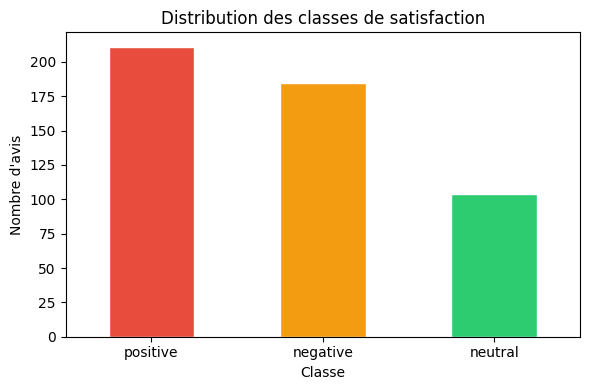

In [4]:
plt.figure(figsize=(6, 4))
df['satisfaction'].value_counts().plot(
    kind='bar',
    color=['#e74c3c', '#f39c12', '#2ecc71'],
    edgecolor='white'
)
plt.title('Distribution des classes de satisfaction')
plt.xlabel('Classe')
plt.ylabel("Nombre d'avis")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Préparation du texte et encodage des labels

In [5]:
df['clean_Titre']       = df['clean_Titre'].fillna('')
df['clean_commentaire'] = df['clean_commentaire'].fillna('')
df['full_text'] = (
    df['clean_Titre'].astype(str) + ' ' + df['clean_commentaire'].astype(str)
).str.strip()

lens = df['full_text'].str.split().str.len()
print('Longueur moyenne :', round(lens.mean(), 1), 'mots')
print('Longueur max     :', lens.max(), 'mots')
print('Percentile 95    :', int(np.percentile(lens, 95)), 'mots')

Longueur moyenne : 23.0 mots
Longueur max     : 204 mots
Percentile 95    : 60 mots


In [6]:
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['satisfaction'])
print('Classes :', label_encoder.classes_)
print('Mapping :', dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

Classes : ['negative' 'neutral' 'positive']
Mapping : {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}


## Découpage train / test

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    df['full_text'], df['label'],
    test_size=0.2, stratify=df['label'], random_state=42
)
print(f'Train : {len(X_train)}  |  Test : {len(X_test)}')
print()
print('Distribution train :')
print(pd.Series(label_encoder.inverse_transform(y_train)).value_counts())
print()
print('Distribution test :')
print(pd.Series(label_encoder.inverse_transform(y_test)).value_counts())

Train : 400  |  Test : 100

Distribution train :
positive    169
negative    148
neutral      83
Name: count, dtype: int64

Distribution test :
positive    42
negative    37
neutral     21
Name: count, dtype: int64


## Chargement de DistilBERT (poids gelés)

On charge `DistilBertModel` (pas `ForSequenceClassification`) — uniquement pour extraire
les embeddings `[CLS]`. Tous les paramètres sont figés avec `requires_grad = False`.

In [8]:
MODEL_NAME = 'distilbert-base-multilingual-cased'

tokenizer  = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)
model_bert = DistilBertModel.from_pretrained(MODEL_NAME).to(DEVICE)
model_bert.eval()

for param in model_bert.parameters():
    param.requires_grad = False

n_params = sum(p.numel() for p in model_bert.parameters())
print(f'Modèle : {MODEL_NAME}')
print(f'Paramètres : {n_params:,} (tous gelés — zéro fine-tuning)')

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 18015.22it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modèle : distilbert-base-multilingual-cased
Paramètres : 134,734,080 (tous gelés — zéro fine-tuning)


## Extraction des embeddings [CLS]

Pour chaque texte, on extrait le vecteur du token `[CLS]` (dim 768)
qui encode le sens global de la phrase.

In [9]:
def extract_embeddings(texts, batch_size=32, max_length=128):
    all_emb = []
    texts = list(texts)
    for i in range(0, len(texts), batch_size):
        batch   = texts[i : i + batch_size]
        encoded = tokenizer(
            batch, padding=True, truncation=True,
            max_length=max_length, return_tensors='pt'
        ).to(DEVICE)
        with torch.no_grad():
            out = model_bert(**encoded)
        cls_vec = out.last_hidden_state[:, 0, :].cpu().numpy()
        all_emb.append(cls_vec)
        if (i // batch_size + 1) % 5 == 0:
            print(f'  {min(i+batch_size, len(texts))}/{len(texts)} textes')
    return np.vstack(all_emb)

print('Extraction Train...')
X_train_emb = extract_embeddings(X_train.values)
print(f'Shape train : {X_train_emb.shape}')

print('Extraction Test...')
X_test_emb = extract_embeddings(X_test.values)
print(f'Shape test  : {X_test_emb.shape}')

Extraction Train...
  160/400 textes
  320/400 textes
Shape train : (400, 768)
Extraction Test...
Shape test  : (100, 768)


## Classifier léger sur les embeddings

Une **régression logistique** est entraînée sur les vecteurs CLS.
C'est le seul entraînement ici — DistilBERT n'est pas modifié.

In [10]:
clf = LogisticRegression(
    max_iter=1000, class_weight='balanced', C=1.0, random_state=42
)
clf.fit(X_train_emb, y_train)
print('Régression logistique entraînée.')

Régression logistique entraînée.


## Évaluation

In [11]:
y_pred  = clf.predict(X_test_emb)
y_probs = clf.predict_proba(X_test_emb)

print('DistilBERT (embeddings gelés) + Régression Logistique')
print('=' * 55)
print(classification_report(y_test, y_pred,
      target_names=label_encoder.classes_, zero_division=0))
print(f'Accuracy          : {accuracy_score(y_test, y_pred):.4f}')
print(f'Balanced Accuracy : {balanced_accuracy_score(y_test, y_pred):.4f}')
print(f'F1 Macro          : {f1_score(y_test, y_pred, average="macro", zero_division=0):.4f}')
print(f'F1 Weighted       : {f1_score(y_test, y_pred, average="weighted", zero_division=0):.4f}')

DistilBERT (embeddings gelés) + Régression Logistique
              precision    recall  f1-score   support

    negative       0.55      0.65      0.59        37
     neutral       0.31      0.38      0.34        21
    positive       0.67      0.48      0.56        42

    accuracy                           0.52       100
   macro avg       0.51      0.50      0.50       100
weighted avg       0.55      0.52      0.52       100

Accuracy          : 0.5200
Balanced Accuracy : 0.5019
F1 Macro          : 0.4962
F1 Weighted       : 0.5241


## Matrice de confusion

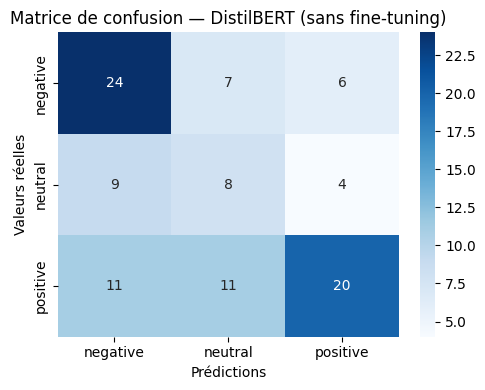

In [12]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Prédictions')
plt.ylabel('Valeurs réelles')
plt.title('Matrice de confusion — DistilBERT (sans fine-tuning)')
plt.tight_layout()
plt.show()

## Courbes ROC

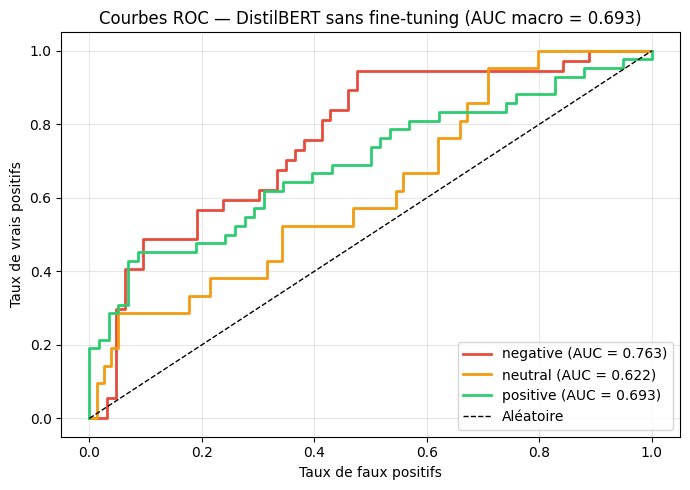

AUC Macro : 0.6929


In [13]:
n_classes = len(label_encoder.classes_)
y_bin     = label_binarize(y_test, classes=list(range(n_classes)))
colors    = ['#e74c3c', '#f39c12', '#2ecc71']

plt.figure(figsize=(7, 5))
for i, (cls, color) in enumerate(zip(label_encoder.classes_, colors)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_probs[:, i])
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f'{cls} (AUC = {auc(fpr, tpr):.3f})')

auc_mac = roc_auc_score(y_bin, y_probs, average='macro', multi_class='ovr')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aléatoire')
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title(f'Courbes ROC — DistilBERT sans fine-tuning (AUC macro = {auc_mac:.3f})')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f'AUC Macro : {auc_mac:.4f}')